<a href="https://colab.research.google.com/github/zinebidrissijanati1-debug/ERF-REPO/blob/main/ERF_n_estimators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== n_estimators: 50 ===
Selected Features: [ 1  4  7  9 10 16 18 21 23 24 26 28]
Accuracy: 0.9824
Confusion Matrix:
[[204   8]
 [  2 355]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       212
           1       0.98      0.99      0.99       357

    accuracy                           0.98       569
   macro avg       0.98      0.98      0.98       569
weighted avg       0.98      0.98      0.98       569


=== n_estimators: 100 ===
Selected Features: [ 1  4  7  9 10 13 14 20 21 23 24 26 27 28 29]
Accuracy: 0.9789
Confusion Matrix:
[[204   8]
 [  4 353]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       212
           1       0.98      0.99      0.98       357

    accuracy                           0.98       569
   macro avg       0.98      0.98      0.98       569
weighted avg       0.98      0.98      0.98       569


=== n_e

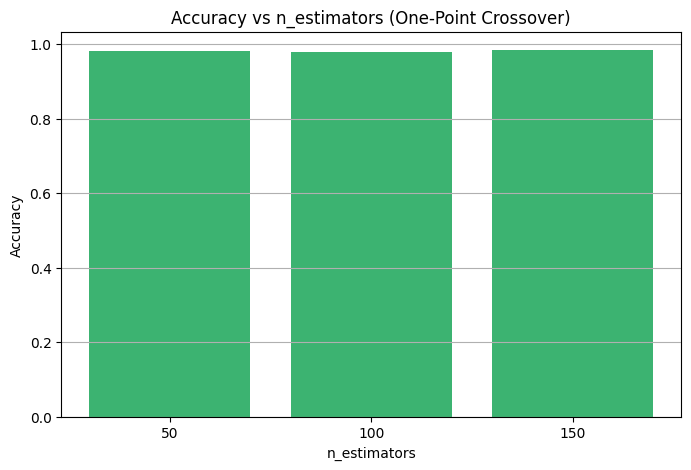

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
n_features = X.shape[1]

# Fixed Parameters
iteration = 20
pop_size = 100
mutation_rate = 0.1
max_depth = None
criterion = 'gini'
bootstrap = True
random_state = 0

# One-point crossover
def one_point_crossover(pop):
    children = []
    for i in range(0, len(pop), 2):
        if i + 1 < len(pop):
            point = np.random.randint(1, len(pop[i]) - 1)
            child1 = np.concatenate((pop[i][:point], pop[i+1][point:]))
            child2 = np.concatenate((pop[i+1][:point], pop[i][point:]))
            children.extend([child1, child2])
        else:
            children.append(pop[i])
    return children

# Other GA components
def initial_population(size, length):
    return [np.random.randint(2, size=length) for _ in range(size)]

def decode_chromosome(chromosome):
    return np.where(chromosome == 1)[0]

def selection(pop, scores):
    next_gen = []
    for _ in range(len(pop)):
        i1, i2 = np.random.randint(0, len(pop), 2)
        winner = pop[i1] if scores[i1] > scores[i2] else pop[i2]
        next_gen.append(winner)
    return next_gen

def mutation(pop, rate):
    mutated = []
    for individual in pop:
        if np.random.rand() < rate:
            idx = np.random.randint(len(individual))
            individual[idx] = 1 - individual[idx]
        mutated.append(individual)
    return mutated

# Evaluation for multiple n_estimators values
estimators_list = [50, 100, 150]
results = {}

for n_estimators in estimators_list:
    print(f"\n=== n_estimators: {n_estimators} ===")
    start_time = time.time()
    population = initial_population(pop_size, n_features)
    best_individual = None
    best_score = 0

    def cross_val_fitness(chromosome):
        selected = decode_chromosome(chromosome)
        if len(selected) == 0:
            return 0.0
        kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
        scores = []
        for train_idx, test_idx in kf.split(X):
            model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                           criterion=criterion, bootstrap=bootstrap, random_state=random_state)
            model.fit(X[train_idx][:, selected], y[train_idx])
            preds = model.predict(X[test_idx][:, selected])
            scores.append(accuracy_score(y[test_idx], preds))
        return np.mean(scores)

    for gen in range(iteration):
        scores = [cross_val_fitness(ind) for ind in population]
        max_idx = np.argmax(scores)
        if scores[max_idx] > best_score:
            best_score = scores[max_idx]
            best_individual = population[max_idx]

        population = selection(population, scores)
        population = one_point_crossover(population)
        population = mutation(population, mutation_rate)

    selected_features = decode_chromosome(best_individual)
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, criterion=criterion,
                                   bootstrap=bootstrap, random_state=random_state)
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    all_preds, all_true = [], []

    for train_idx, test_idx in kf.split(X):
        model.fit(X[train_idx][:, selected_features], y[train_idx])
        preds = model.predict(X[test_idx][:, selected_features])
        all_preds.extend(preds)
        all_true.extend(y[test_idx])

    acc = accuracy_score(all_true, all_preds)
    results[n_estimators] = {
        "accuracy": acc,
        "selected_features": selected_features,
        "confusion_matrix": confusion_matrix(all_true, all_preds),
        "report": classification_report(all_true, all_preds, output_dict=True)
    }

    print(f"Selected Features: {selected_features}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(all_true, all_preds))
    print("Classification Report:")
    print(classification_report(all_true, all_preds))

# Plot accuracy vs n_estimators
plt.figure(figsize=(8, 5))
plt.bar([str(k) for k in results.keys()],
        [results[k]['accuracy'] for k in results],
        color='mediumseagreen')
plt.title('Accuracy vs n_estimators (One-Point Crossover)')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.grid(axis='y')
plt.show()
